In [2]:
import pandas as pd 
data = pd.read_csv(r"C:\Users\pc\Desktop\Python\ML code\outliers\placement (1).csv")
data

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [4]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors= 5)

In [5]:
from sklearn.model_selection import train_test_split
X = data[["cgpa","placement_exam_marks"]]
y = data["placed"]
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state= 42, stratify = y)
model.fit(X_train,y_train)

KNeighborsClassifier()

In [6]:
pred = model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.484

In [8]:
accuracies = []
for epocs in range (1,21):
    model = KNeighborsClassifier(n_neighbors= epocs)
    model.fit(X_train,y_train)
    n_pred  = model.predict(X_test)
    acc = accuracy_score(y_test,n_pred)
    accuracies.append(acc)
print(accuracies)

[0.484, 0.496, 0.468, 0.472, 0.484, 0.472, 0.48, 0.46, 0.492, 0.476, 0.484, 0.504, 0.492, 0.512, 0.48, 0.496, 0.488, 0.476, 0.468, 0.48]


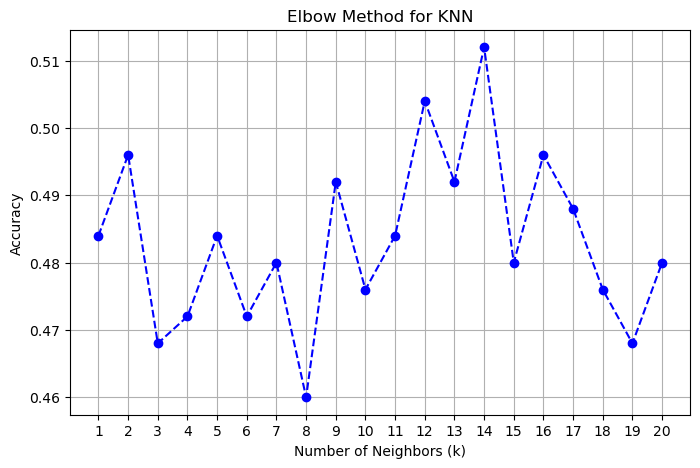

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1,21), accuracies, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Elbow Method for KNN")
plt.xticks(range(1,21))
plt.grid(True)
plt.show()

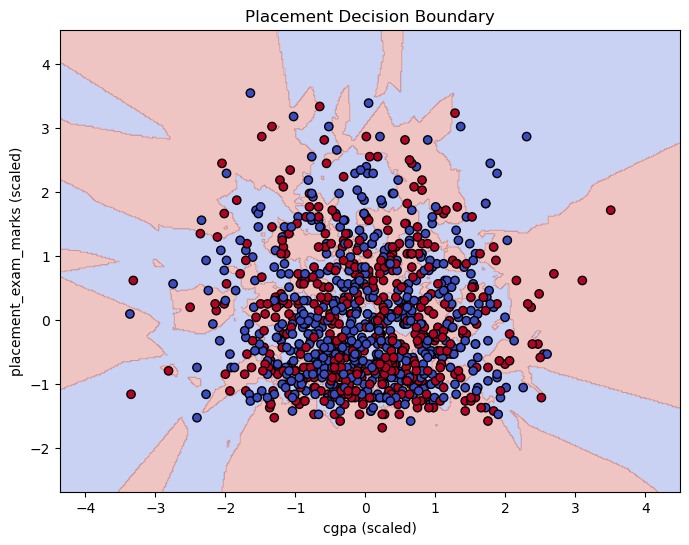

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

# features and target
X_p = data[['cgpa', 'placement_exam_marks']].values
y_p = data['placed'].values

# scale (KNN is distance-based, scaling matters)
scaler_p = StandardScaler()
X_p_scaled = scaler_p.fit_transform(X_p)

# fit
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_p_scaled, y_p)

# meshgrid over the scaled feature space
h = 0.02
x_min, x_max = X_p_scaled[:, 0].min() - 1, X_p_scaled[:, 0].max() + 1
y_min, y_max = X_p_scaled[:, 1].min() - 1, X_p_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_p_scaled[:, 0], X_p_scaled[:, 1], c=y_p, cmap='coolwarm', edgecolors='k')
plt.xlabel('cgpa (scaled)')
plt.ylabel('placement_exam_marks (scaled)')
plt.title('Placement Decision Boundary')
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
df = pd.read_csv(r"C:\Users\pc\Desktop\Python\ML code\outliers\weight-height.csv") 
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [11]:
df["Gender"] = df["Gender"].map({"Male" : 1,"Female" : 0})
df

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801
...,...,...,...
9995,0,66.172652,136.777454
9996,0,67.067155,170.867906
9997,0,63.867992,128.475319
9998,0,69.034243,163.852461


In [12]:
df.isnull().sum().any()

np.False_

In [13]:
X = df[["Gender","Height"]]
y = df["Weight"]
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state= 42)

In [14]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
train_scaled = scale.fit_transform(X_train)
test_scaled =scale.transform(X_test)
train_scaled


array([[ 1.00588398, -0.53914706],
       [ 1.00588398,  1.71113721],
       [-0.99415044,  0.00898355],
       ...,
       [-0.99415044, -0.52641877],
       [ 1.00588398,  0.7094092 ],
       [-0.99415044,  0.32280629]], shape=(7500, 2))

In [15]:
knn.fit(train_scaled,y_train)
predict = knn.predict(test_scaled)

In [16]:
from sklearn.metrics import r2_score
r2_score(y_test,predict)

0.8790335687379954

In [17]:
accuracy = []
for epocs in range(1,21):
    m = KNeighborsRegressor(n_neighbors= epocs)
    m.fit(train_scaled,y_train)
    p = m.predict(test_scaled)
    acc = r2_score(y_test,p)
    accuracy.append(acc)
print(accuracy)

[0.8096630989391331, 0.8554133997297995, 0.8701073450803811, 0.8748734589827927, 0.8790335687379954, 0.8831073845985699, 0.8862458989025792, 0.8879142793554808, 0.8900024878299523, 0.8915105642895889, 0.892262749295261, 0.8932885705162348, 0.8938560522697945, 0.8944996537860572, 0.8949279829717504, 0.895624437550733, 0.8960147076701199, 0.8964775015543804, 0.896914545417442, 0.8973474344472868]


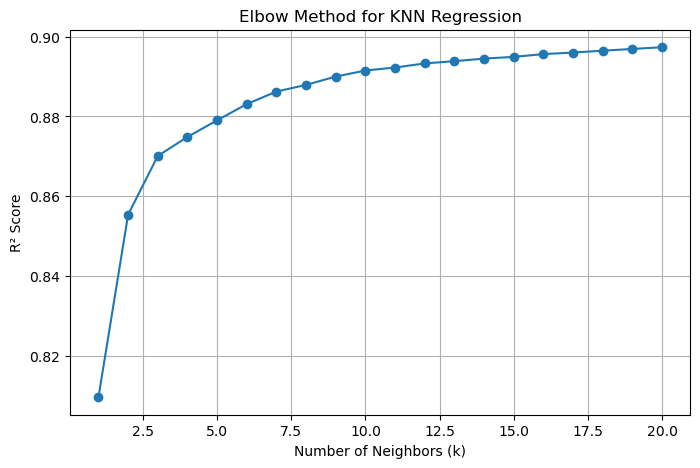

In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(1,21), accuracy, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("R² Score")
plt.title("Elbow Method for KNN Regression")
plt.grid(True)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# assume X has 2 features (for easy 2D plotting), y is labels
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

# create a mesh grid across the feature space
h = 0.02  # step size — smaller = smoother boundary, slower to compute
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# predict for every point on the grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')  # colored regions
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')  # actual points
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundary (k={knn.n_neighbors})')
plt.show()

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

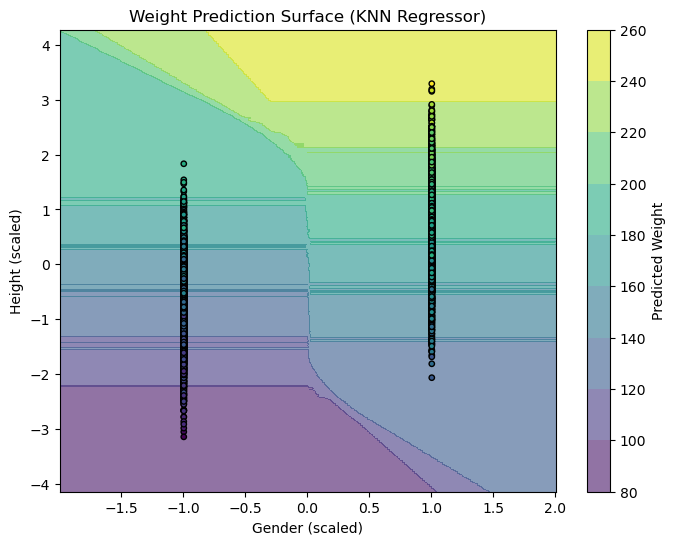

In [21]:
h = 0.02
x_min, x_max = train_scaled[:, 0].min() - 1, train_scaled[:, 0].max() + 1
y_min, y_max = train_scaled[:, 1].min() - 1, train_scaled[:, 1].max() + 1
xx2, yy2 = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z2 = m.predict(np.c_[xx2.ravel(), yy2.ravel()])
Z2 = Z2.reshape(xx2.shape)

plt.figure(figsize=(8, 6))
contour = plt.contourf(xx2, yy2, Z2, alpha=0.6, cmap='viridis')  # continuous colormap, not discrete classes
plt.colorbar(contour, label='Predicted Weight')
plt.scatter(train_scaled[:, 0], train_scaled[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=15)
plt.xlabel('Gender (scaled)')
plt.ylabel('Height (scaled)')
plt.title('Weight Prediction Surface (KNN Regressor)')
plt.show()